In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("loan_approval_data.csv")

In [3]:
df.sample(15)
df.info()
df
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


#Handle Missing Values

In [4]:
categorical_cols = df.select_dtypes(include = ["object"]).columns
numerical_cols = df.select_dtypes(include = ["float64"]).columns

In [5]:
categorical_cols.size
numerical_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [6]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

cols_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cols_imp.fit_transform(df[categorical_cols])

In [7]:
df.sample(15)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
547,548.00,10415.000000,1525.0,Salaried,57.0,Married,3.000000,673.000000,1.0,0.580000,232.0,24802.792632,7984.000000,12.0,Home,Rural,Not Graduate,Male,Private,No
113,114.00,18198.000000,5604.0,Self-employed,40.0,Married,2.000000,634.000000,1.0,0.600000,4019.0,48384.000000,31204.000000,48.0,Education,Semiurban,Graduate,Female,Private,No
966,967.00,15575.000000,1382.0,Self-employed,33.0,Married,3.000000,554.000000,3.0,0.390000,18384.0,30666.000000,28632.000000,84.0,Home,Urban,Graduate,Female,Government,No
430,431.00,16191.000000,2043.0,Unemployed,37.0,Married,3.000000,719.000000,1.0,0.160000,10715.0,6200.000000,14526.000000,36.0,Business,Rural,Not Graduate,Male,Government,Yes
569,570.00,10852.571579,5724.0,Salaried,28.0,Married,3.000000,736.000000,3.0,0.370000,7624.0,24802.792632,17347.000000,60.0,Education,Urban,Graduate,Male,MNC,Yes
950,951.00,16422.000000,6525.0,Salaried,38.0,Married,2.000000,619.000000,0.0,0.370000,5392.0,6189.000000,5098.000000,84.0,Business,Semiurban,Graduate,Male,Private,No
279,280.00,18538.000000,3930.0,Unemployed,45.0,Married,1.000000,757.000000,2.0,0.210000,2114.0,19199.000000,39041.000000,48.0,Home,Urban,Graduate,Male,Private,Yes
769,770.00,10512.000000,4815.0,Salaried,33.0,Married,3.000000,749.000000,0.0,0.300000,16409.0,12877.000000,20522.825263,36.0,Business,Rural,Graduate,Male,Private,Yes
108,501.22,16820.000000,8407.0,Contract,46.0,Single,1.000000,676.033684,3.0,0.210000,8123.0,8328.000000,4679.000000,60.0,Home,Urban,Graduate,Male,Private,No
844,845.00,12147.000000,3374.0,Contract,32.0,Married,1.000000,757.000000,0.0,0.347263,16059.0,20446.000000,13262.000000,60.0,Home,Semiurban,Graduate,Male,Business,Yes


EDA : Exploratory Data Analysis

Text(0.5, 1.0, 'Loan Approved or not')

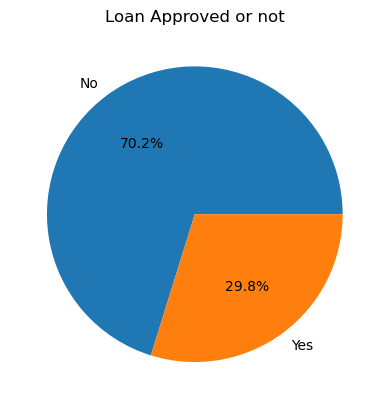

In [8]:
#How balanced the data is 

classes_count = df["Loan_Approved"].value_counts()

plt.pie(classes_count , labels = ["No" , "Yes"] , autopct = "%1.1f%%")
plt.title("Loan Approved or not")

[Text(0, 0, '722'), Text(0, 0, '278')]

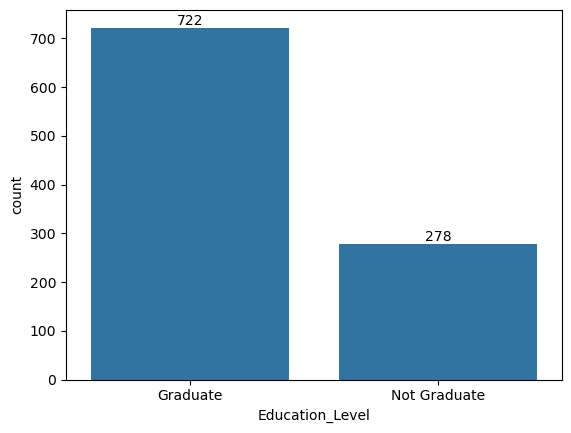

In [9]:
#Categories 
import seaborn as sns

 #gender_cnt = df["Gender"].value_counts()
#ax = sns.barplot(gender_cnt)
#ax.bar_label(ax.containers[0])

edu_count = df["Education_Level"].value_counts()
ax = sns.barplot(edu_count)
ax.bar_label(ax.containers[0])


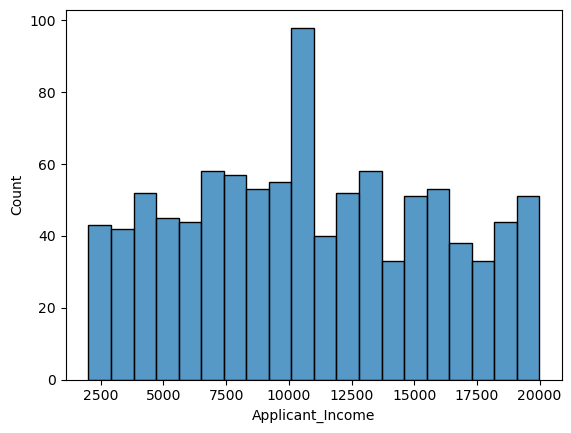

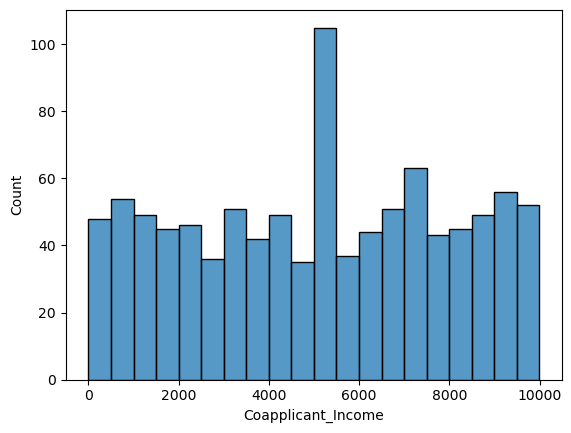

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20
)

plt.show()

sns.histplot(
    data=df,
    x="Coapplicant_Income",
    bins=20
)

plt.show()

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

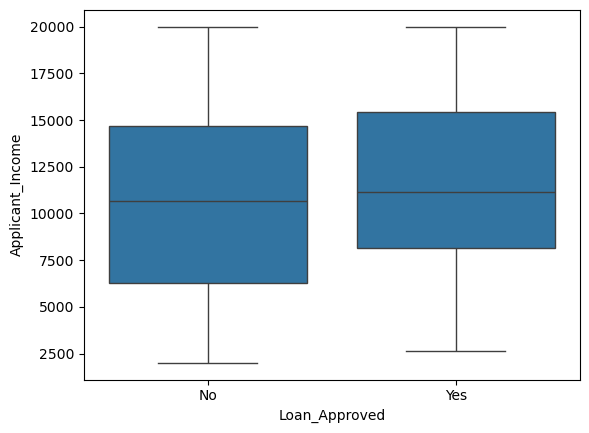

In [11]:
#Outliers

sns.boxplot(
    data = df ,
    x = "Loan_Approved",
    y = "Applicant_Income"
)

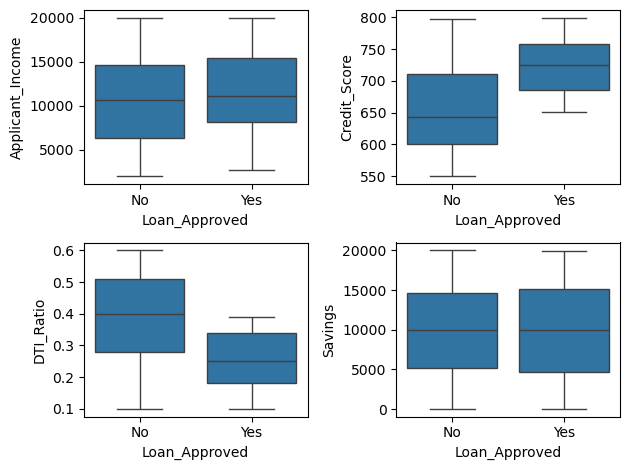

In [12]:
fig , axes = plt.subplots(2,2)

sns.boxplot(ax = axes[0,0] , data = df , x = "Loan_Approved", y = "Applicant_Income" )
sns.boxplot(ax = axes[0,1] , data = df , x = "Loan_Approved", y = "Credit_Score" )
sns.boxplot(ax = axes[1,0] , data = df , x = "Loan_Approved", y = "DTI_Ratio" )
sns.boxplot(ax = axes[1,1] , data = df , x = "Loan_Approved", y = "Savings" )

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

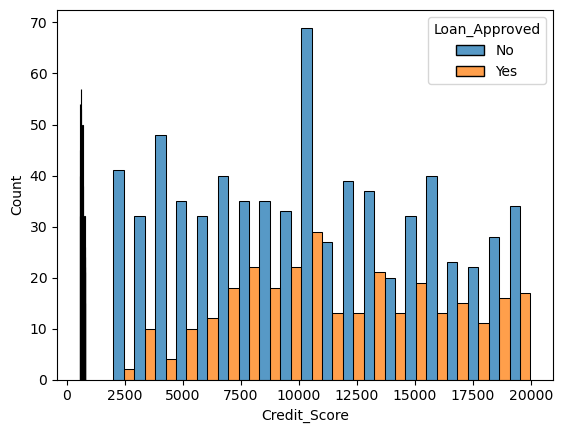

In [13]:
#Credit Score 

sns.histplot(
    data=df,
    x="Credit_Score",
    hue = "Loan_Approved",
    bins=20,
    multiple = "dodge"
)

sns.histplot(
    data=df,
    x="Applicant_Income",
    hue = "Loan_Approved",
    bins=20,
    multiple = "dodge"
)

In [14]:
df = df.drop("Applicant_ID", axis=1)

In [15]:
df.head(4)

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No


Encoding 

In [16]:
from sklearn.preprocessing import LabelEncoder , OneHotEncoder

le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])


In [17]:
df.sample(5)

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
227,13296.0,1796.0,Unemployed,39.971579,Single,0.0,716.0,3.0,0.32,14120.0,20044.0,26198.0,12.0,Home,Urban,0,Male,Business,1
905,15226.0,8264.0,Contract,23.000000,Single,1.0,595.0,1.0,0.43,10057.0,47999.0,29000.0,72.0,Personal,Rural,0,Male,Government,0
632,11911.0,7175.0,Salaried,38.000000,Married,1.0,780.0,3.0,0.57,80.0,30763.0,21504.0,12.0,Home,Urban,1,Female,Government,0
324,6465.0,9437.0,Salaried,43.000000,Single,3.0,611.0,0.0,0.57,10286.0,29677.0,19922.0,24.0,Business,Rural,0,Male,Government,0
867,17343.0,7121.0,Salaried,50.000000,Single,1.0,587.0,1.0,0.40,4262.0,40391.0,4192.0,60.0,Car,Rural,1,Female,Private,0


In [18]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Reload dataset if needed
# df = pd.read_csv("your_file.csv")

cols = [
    "Employment_Status",
    "Marital_Status",
    "Loan_Purpose",
    "Property_Area",
    "Gender",
    "Employer_Category"
]

# One Hot Encoder
ohe = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore"
)

# Encode categorical columns
encoded = ohe.fit_transform(df[cols])

# Convert encoded array to dataframe
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(cols),
    index=df.index
)

# Drop original categorical columns
df = df.drop(columns=cols)

# Concatenate encoded columns
df = pd.concat([df, encoded_df], axis=1)

# Check result
print(df.head())

   Applicant_Income  Coapplicant_Income   Age  Dependents  Credit_Score  \
0           17795.0              1387.0  51.0         0.0         637.0   
1            2860.0              2679.0  46.0         3.0         621.0   
2            7390.0              2106.0  25.0         2.0         674.0   
3           13964.0              8173.0  40.0         2.0         579.0   
4           13284.0              4223.0  31.0         2.0         721.0   

   Existing_Loans  DTI_Ratio  Savings  Collateral_Value  Loan_Amount  ...  \
0             4.0       0.53  19403.0           45638.0      16619.0  ...   
1             2.0       0.30   2580.0           49272.0      38687.0  ...   
2             4.0       0.20  13844.0            6908.0      27943.0  ...   
3             3.0       0.31   9553.0           10844.0      27819.0  ...   
4             1.0       0.29   9386.0           37629.0      12741.0  ...   

   Loan_Purpose_Education  Loan_Purpose_Home  Loan_Purpose_Personal  \
0              

In [19]:
df.sample(5)

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
405,2412.0,7725.0,56.000000,0.0,676.0,0.0,0.57,10846.0,49410.0,34044.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
909,19589.0,4225.0,31.000000,3.0,752.0,0.0,0.37,1389.0,12314.0,25281.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
557,2384.0,2113.0,39.971579,1.0,726.0,4.0,0.34,11882.0,48542.0,13312.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
645,8376.0,7705.0,51.000000,3.0,627.0,2.0,0.22,17285.0,21612.0,31636.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
385,10002.0,2255.0,49.000000,2.0,627.0,2.0,0.26,13435.0,4267.0,3058.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


#Correlational HeatMaps

In [20]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()
corr_matrix

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
Applicant_Income,1.000000,0.007545,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,-0.024143,...,0.032794,0.074209,-0.031234,0.004845,-0.036260,-0.020871,-0.025011,0.102589,-0.044639,-0.011995
Coapplicant_Income,0.007545,1.000000,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,0.001596,...,0.028000,0.016022,0.059549,-0.010058,0.030045,-0.010148,-0.001146,0.037640,0.004312,-0.047929
Age,-0.023988,0.014306,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,0.013502,...,-0.006283,0.029865,0.037293,0.003100,-0.025661,0.048402,-0.066041,0.021232,-0.012960,0.072462
Dependents,-0.026658,-0.026733,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,-0.017409,...,-0.044642,0.027343,-0.005785,-0.032278,0.024082,0.013706,-0.009250,-0.018757,0.030197,-0.054147
Credit_Score,-0.009818,0.058423,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,0.001002,...,0.026013,-0.008658,0.015324,-0.006946,0.004445,-0.039739,-0.007076,0.066736,-0.000049,-0.046087
Existing_Loans,-0.010457,0.012418,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,-0.021035,...,-0.010035,0.001777,0.023212,-0.053971,0.035629,-0.038762,-0.009642,0.030520,-0.019306,0.045391
DTI_Ratio,-0.009107,0.058078,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,0.075784,...,0.040432,-0.014125,-0.036648,0.044898,-0.006156,0.009624,-0.007214,0.002090,-0.003506,0.026018
Savings,-0.028358,-0.015047,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,-0.012208,...,0.032558,-0.012217,-0.028948,0.005438,0.016833,-0.006667,-0.011683,0.004381,-0.030208,0.027178
Collateral_Value,0.018789,0.009457,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,0.002660,...,0.040406,-0.050975,-0.007120,0.020061,0.007975,0.000897,0.035760,-0.013464,-0.014480,-0.009655
Loan_Amount,-0.024143,0.001596,0.013502,-0.017409,0.001002,-0.021035,0.075784,-0.012208,0.002660,1.000000,...,-0.006119,-0.000930,0.032498,0.040206,-0.050076,0.103456,0.013108,-0.025975,0.013923,-0.026566


In [21]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

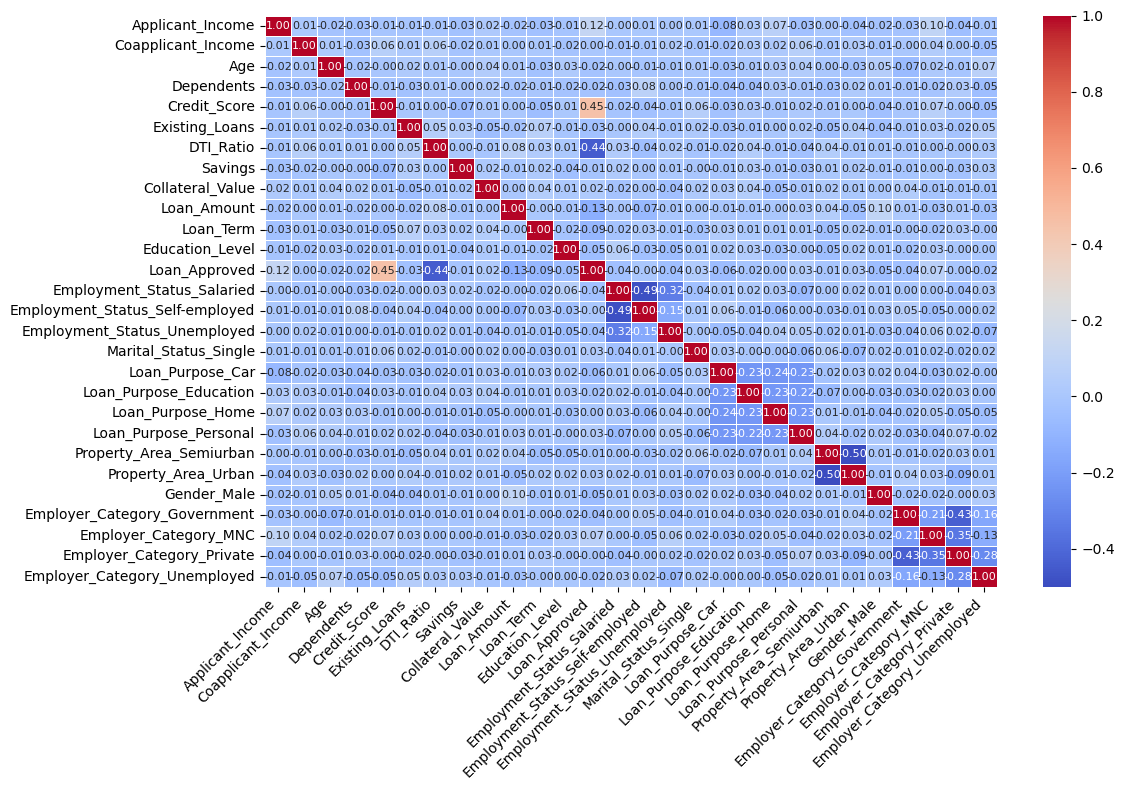

In [22]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",          # 2 decimal places
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size": 8}
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#Training & Evaluation Models

In [37]:
from sklearn.model_selection import train_test_split
import numpy as np

X = df.drop("Loan_Approved" , axis = 1)
Y = df["Loan_Approved"]

X_train , X_test , Y_train , Y_test = train_test_split (
    X , Y , test_size = 0.2 , random_state = 42
)

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [68]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression 

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, Y_train)

y_pred = log_model.predict(X_test_scaled)

In [69]:
from sklearn.metrics import confusion_matrix , precision_score , recall_score , f1_score , accuracy_score

print("Accuracy :", accuracy_score(Y_test, y_pred)*100)
print("Recall :", recall_score(Y_test, y_pred)*100)
print("Precision :", precision_score(Y_test, y_pred)*100)
print("f1_score : " , f1_score(Y_test , y_pred )*100)
print("CM : " , confusion_matrix(Y_test,y_pred))

Accuracy : 86.5
Recall : 77.04918032786885
Precision : 78.33333333333333
f1_score :  77.68595041322314
CM :  [[126  13]
 [ 14  47]]


KNN

In [72]:
from sklearn.neighbors import KNeighborsClassifier

knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_train , Y_train)


y_pred = knn_classifier.predict(X_test)

In [86]:
#Scaled Data

knn_classifier.fit(X_train_scaled, Y_train)

y_pred = knn_classifier.predict(X_test_scaled)

print("Accuracy :", accuracy_score(Y_test, y_pred)*100)
print("Recall :", recall_score(Y_test, y_pred)*100)
print("Precision :", precision_score(Y_test, y_pred)*100)
print("f1_score : " , f1_score(Y_test , y_pred )*100)
print("CM : " , confusion_matrix(Y_test,y_pred))

Accuracy : 76.0
Recall : 52.459016393442624
Precision : 62.745098039215684
f1_score :  57.14285714285714
CM :  [[120  19]
 [ 29  32]]


Naive Bayes

In [87]:
from sklearn.naive_bayes import GaussianNB

gnb_model = GaussianNB()
gnb_model.fit(X_train_scaled, Y_train)

y_pred = gnb_model.predict(X_test_scaled)

print("Accuracy :", accuracy_score(Y_test, y_pred)*100)
print("Recall :", recall_score(Y_test, y_pred)*100)
print("Precision :", precision_score(Y_test, y_pred)*100)
print("f1_score : " , f1_score(Y_test , y_pred )*100)
print("CM : " , confusion_matrix(Y_test,y_pred))

Accuracy : 86.5
Recall : 73.77049180327869
Precision : 80.35714285714286
f1_score :  76.92307692307693
CM :  [[128  11]
 [ 16  45]]
